In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import config
from data_utils import sort_data

In [2]:
data = pd.read_parquet(config.UNTIDY_DATA_PATH)
data.columns = data.columns.str.lower()


In [3]:
data.head()

,web_name_id,first_name_id,second_name_id,status_id,team_name_id,position_id,season_id,player_code_id,team_code_id,gw_id,match_id,recoveries,dreamteam_count,creativity,tackles_won_percent,corners_and_indirect_freekicks_order,bps,accurate_passes,transfers_in,expected_goals_conceded,threat_rank,ground_duels_won,duels_lost,tackles_won,finish_min,xgot,ep_this,expected_goals_conceded_per_90,threat_rank_type,was_fouled,accurate_long_balls_percent,accurate_passes_percent,ground_duels_won_percent,transfers_out,touches,selected_rank_type,tackles,interceptions,event_points,transfers_out_event,clearances,gk_accurate_long_balls,now_cost_rank,goals,team_goals_conceded,value_form,fouls_committed,threat,penalties_missed,influence_rank_type,bonus,blocks,high_claim,form_rank,ep_next,shots_on_target,value_season,minutes_played,dribbled_past,expected_goals,influence,influence_rank,expected_goal_involvements_per_90,now_cost,chance_of_playing_next_round,penalties_scored,cost_change_start,ict_index,id,touches_opposition_box,set_piece_threat,cost_change_event,selected_rank,penalties_order,expected_assists_per_90,cost_change_start_fall,form,selected_by_percent,ict_index_rank,expected_assists,accurate_crosses,points_per_game_rank_type,start_min,team_strength,ict_index_rank_type,points_per_game,final_third_passes,accurate_long_balls,aerial_duels_won,offsides,points_per_game_rank,total_shots,total_points,expected_goal_involvements,xa,creativity_rank_type,aerial_duels_won_percent,goals_prevented,chances_created,cost_change_event_fall,expected_goals_per_90,goals_conceded,xgot_faced,direct_freekicks_order,gk_accurate_passes,successful_dribbles,headed_clearances,big_chances_missed,saves,sweeper_actions,form_rank_type,duels_won,creativity_rank,accurate_crosses_percent,successful_dribbles_percent,assists,xg,transfers_in_event,chance_of_playing_this_round,now_cost_rank_type
0,Milner,James,Milner,a,Brighton,Midfielder,2024-2025,15157,36,1,24-25-prem-everton-vs-brighton-&-hove-albion,0,0,43.8,50,1,10,28,513,0.45,137,4,2,2,82,0.0,1.6,0.5,76,0,33,85,80,421,48,174,4,0,2,421,0,0,172,0,0,0.4,1,4,0,22,0,2,0,120,1.6,0,0.4,82,0,0.0,22.4,58,0.12,5.0,<NA>,0,0,7.0,134,2,40.0,0,471,<NA>,0.12,0,2.0,0.1,30,0.11,2,49,0,3,23,2.0,2,1,0,0,120,0,2,0.11,0.11,5,0,0.0,3,0,0.0,0,0.0,<NA>,0,0,0,0,0,0,49,4,6,29,0,0,0.0,513,<NA>,107
1,Milner,James,Milner,a,Brighton,Midfielder,2024-2025,15157,36,2,24-25-prem-brighton-&-hove-albion-vs-mancheste...,2,0,66.2,0,1,22,22,2267,1.77,126,3,1,0,73,0.0,2.0,1.04,76,1,0,73,75,1548,42,161,1,1,2,635,2,0,177,0,1,0.4,1,12,0,52,0,0,0,139,1.0,1,0.8,73,0,0.16,28.6,133,0.18,5.0,<NA>,0,0,10.7,134,2,40.0,0,448,<NA>,0.09,0,2.0,0.1,61,0.15,1,69,0,3,41,2.0,6,0,0,0,143,2,4,0.31,0.04,17,0,0.0,1,0,0.09,0,0.0,<NA>,0,1,0,0,0,0,67,3,19,100,100,0,0.16,1189,<NA>,111
2,Milner,James,Milner,d,Brighton,Midfielder,2024-2025,15157,36,3,24-25-prem-arsenal-vs-brighton-&-hove-albion,0,0,66.3,0,1,24,2,4199,1.98,167,0,1,0,17,0.0,0.7,1.05,98,0,0,100,0,4535,4,167,0,1,1,1998,0,0,185,0,0,0.3,1,12,0,84,0,0,0,175,1.7,0,1.0,17,0,0.16,28.6,199,0.17,5.0,75,0,0,10.7,134,0,40.0,0,461,<NA>,0.08,0,1.7,0.1,104,0.15,0,92,0,3,66,1.7,0,0,0,0,188,0,5,0.31,0.0,30,0,0.0,0,0,0.09,0,0.0,<NA>,0,0,0,0,0,0,87,0,34,0,0,0,0.0,472,<NA>,118
3,Milner,James,Milner,a,Brighton,Midfielder,2024-2025,15157,36,38,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,0,0,66.3,0,<NA>,27,0,5014,1.98,429,0,0,0,93,0.0,0.0,1.05,220,0,0,0,0,10991,1,227,0,0,1,0,0,0,192,0,0,0.0,0,12,0,212,0,0,0,404,0.0,0,1.2,1,0,0.16,28.6,465,0.16,5.0,100,0,0,10.7,134,0,<NA>,0,586,<NA>,0.08,0,0.2,0.0,440,0.15,0,181,93,3,209,1.5,1,0,0,0,388,0,6,0.31,0.0,194,0,0.0,0,0,0.08,0,0.0,<NA>,0,0,0,0,0,0,188,0,342,0,0,0,0.0,0,0,116
4,Milner,James,Milner,a,Brighton,Midfielder,2025-2026,15157,36,1,25-26-prem-brighton-hove-albion-vs-fulham,0,0,0.1,0,5,3,1,14413,0.24,317,0,0,0,90,0.0,0.0,1.61,166,0,0,0,0,20304,1,155,0,0,1,497,0,0,283,0,1,0.0,0,0,0,127,0,0,0,662,-0.5,0,3.1,2,0,0.0,0.0,288,0.57,4.9,100,0,-1,0.0,170,0,<NA>,0,467,1,0.19,1,0.0,0.1,301,0.0,0,119,0,3,14

In [4]:
data["season_id"] = data.season_id.str.replace("-", "", regex=True).str.replace("20", "", regex=True).astype(int)

In [5]:
data = sort_data(data)
data.head()

,web_name_id,first_name_id,second_name_id,status_id,team_name_id,position_id,season_id,player_code_id,team_code_id,gw_id,match_id,recoveries,dreamteam_count,creativity,tackles_won_percent,corners_and_indirect_freekicks_order,bps,accurate_passes,transfers_in,expected_goals_conceded,threat_rank,ground_duels_won,duels_lost,tackles_won,finish_min,xgot,ep_this,expected_goals_conceded_per_90,threat_rank_type,was_fouled,accurate_long_balls_percent,accurate_passes_percent,ground_duels_won_percent,transfers_out,touches,selected_rank_type,tackles,interceptions,event_points,transfers_out_event,clearances,gk_accurate_long_balls,now_cost_rank,goals,team_goals_conceded,value_form,fouls_committed,threat,penalties_missed,influence_rank_type,bonus,blocks,high_claim,form_rank,ep_next,shots_on_target,value_season,minutes_played,dribbled_past,expected_goals,influence,influence_rank,expected_goal_involvements_per_90,now_cost,chance_of_playing_next_round,penalties_scored,cost_change_start,ict_index,id,touches_opposition_box,set_piece_threat,cost_change_event,selected_rank,penalties_order,expected_assists_per_90,cost_change_start_fall,form,selected_by_percent,ict_index_rank,expected_assists,accurate_crosses,points_per_game_rank_type,start_min,team_strength,ict_index_rank_type,points_per_game,final_third_passes,accurate_long_balls,aerial_duels_won,offsides,points_per_game_rank,total_shots,total_points,expected_goal_involvements,xa,creativity_rank_type,aerial_duels_won_percent,goals_prevented,chances_created,cost_change_event_fall,expected_goals_per_90,goals_conceded,xgot_faced,direct_freekicks_order,gk_accurate_passes,successful_dribbles,headed_clearances,big_chances_missed,saves,sweeper_actions,form_rank_type,duels_won,creativity_rank,accurate_crosses_percent,successful_dribbles_percent,assists,xg,transfers_in_event,chance_of_playing_this_round,now_cost_rank_type
0,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,1,24-25-prem-everton-vs-brighton-&-hove-albion,0,0,43.8,50,1,10,28,513,0.45,137,4,2,2,82,0.0,1.6,0.5,76,0,33,85,80,421,48,174,4,0,2,421,0,0,172,0,0,0.4,1,4,0,22,0,2,0,120,1.6,0,0.4,82,0,0.0,22.4,58,0.12,5.0,<NA>,0,0,7.0,134,2,40.0,0,471,<NA>,0.12,0,2.0,0.1,30,0.11,2,49,0,3,23,2.0,2,1,0,0,120,0,2,0.11,0.11,5,0,0.0,3,0,0.0,0,0.0,<NA>,0,0,0,0,0,0,49,4,6,29,0,0,0.0,513,<NA>,107
1,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,2,24-25-prem-brighton-&-hove-albion-vs-mancheste...,2,0,66.2,0,1,22,22,2267,1.77,126,3,1,0,73,0.0,2.0,1.04,76,1,0,73,75,1548,42,161,1,1,2,635,2,0,177,0,1,0.4,1,12,0,52,0,0,0,139,1.0,1,0.8,73,0,0.16,28.6,133,0.18,5.0,<NA>,0,0,10.7,134,2,40.0,0,448,<NA>,0.09,0,2.0,0.1,61,0.15,1,69,0,3,41,2.0,6,0,0,0,143,2,4,0.31,0.04,17,0,0.0,1,0,0.09,0,0.0,<NA>,0,1,0,0,0,0,67,3,19,100,100,0,0.16,1189,<NA>,111
2,Milner,James,Milner,d,Brighton,Midfielder,2425,15157,36,3,24-25-prem-arsenal-vs-brighton-&-hove-albion,0,0,66.3,0,1,24,2,4199,1.98,167,0,1,0,17,0.0,0.7,1.05,98,0,0,100,0,4535,4,167,0,1,1,1998,0,0,185,0,0,0.3,1,12,0,84,0,0,0,175,1.7,0,1.0,17,0,0.16,28.6,199,0.17,5.0,75,0,0,10.7,134,0,40.0,0,461,<NA>,0.08,0,1.7,0.1,104,0.15,0,92,0,3,66,1.7,0,0,0,0,188,0,5,0.31,0.0,30,0,0.0,0,0,0.09,0,0.0,<NA>,0,0,0,0,0,0,87,0,34,0,0,0,0.0,472,<NA>,118
3,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,38,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,0,0,66.3,0,<NA>,27,0,5014,1.98,429,0,0,0,93,0.0,0.0,1.05,220,0,0,0,0,10991,1,227,0,0,1,0,0,0,192,0,0,0.0,0,12,0,212,0,0,0,404,0.0,0,1.2,1,0,0.16,28.6,465,0.16,5.0,100,0,0,10.7,134,0,<NA>,0,586,<NA>,0.08,0,0.2,0.0,440,0.15,0,181,93,3,209,1.5,1,0,0,0,388,0,6,0.31,0.0,194,0,0.0,0,0,0.08,0,0.0,<NA>,0,0,0,0,0,0,188,0,342,0,0,0,0.0,0,0,116
4,Milner,James,Milner,a,Brighton,Midfielder,2526,15157,36,1,25-26-prem-brighton-hove-albion-vs-fulham,0,0,0.1,0,5,3,1,14413,0.24,317,0,0,0,90,0.0,0.0,1.61,166,0,0,0,0,20304,1,155,0,0,1,497,0,0,283,0,1,0.0,0,0,0,127,0,0,0,662,-0.5,0,3.1,2,0,0.0,0.0,288,0.57,4.9,100,0,-1,0.0,170,0,<NA>,0,467,1,0.19,1,0.0,0.1,301,0.0,0,119,0,3,145,2.1,0,0,0,0,265,0,1,0.0

In [6]:
data.shape

(22752, 120)

In [7]:
data.isna().sum().sum()

np.int64(165166)

In [8]:
data.isna().mean()[data.isna().mean()>0].sort_values(ascending=False)

penalties_order                         0.891482
direct_freekicks_order                  0.877110
corners_and_indirect_freekicks_order    0.848233
set_piece_threat                        0.745605
chance_of_playing_this_round            0.333158
chance_of_playing_next_round            0.320675
expected_goals_conceded_per_90          0.147416
selected_rank_type                      0.147416
form_rank                               0.147416
threat_rank                             0.147416
threat_rank_type                        0.147416
dreamteam_count                         0.147416
influence_rank                          0.147416
expected_goal_involvements_per_90       0.147416
influence_rank_type                     0.147416
expected_assists_per_90                 0.147416
points_per_game_rank_type               0.147416
ict_index_rank_type                     0.147416
cost_change_start_fall                  0.147416
ict_index_rank                          0.147416
points_per_game_rank

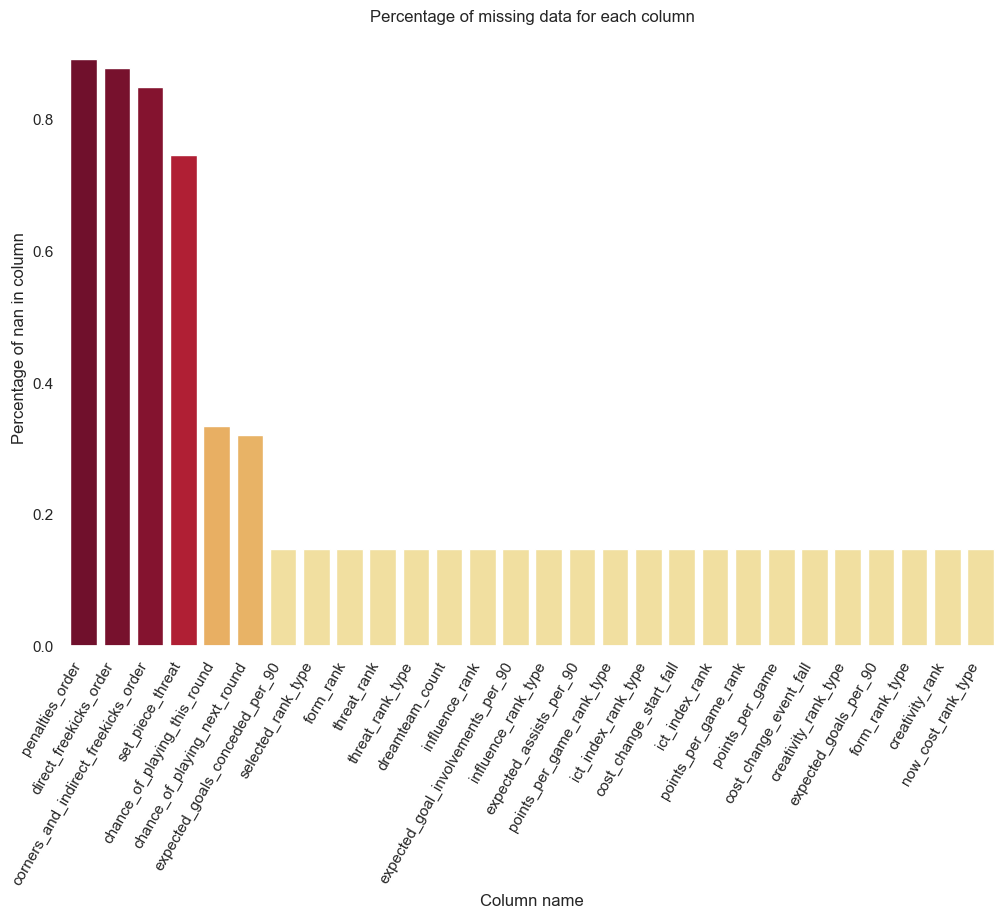

In [9]:
plt.figure(figsize=(12, 8))
s = data.isna().mean()
s = s[s > 0].sort_values(ascending=False)

sns.barplot(x=s.index, y=s, hue=s.index, legend=False, palette=list(plt.cm.YlOrRd((s / s.max()))))
plt.xlabel("Column name")
plt.ylabel("Percentage of nan in column")
plt.title("Percentage of missing data for each column")

plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', alpha=0.5);

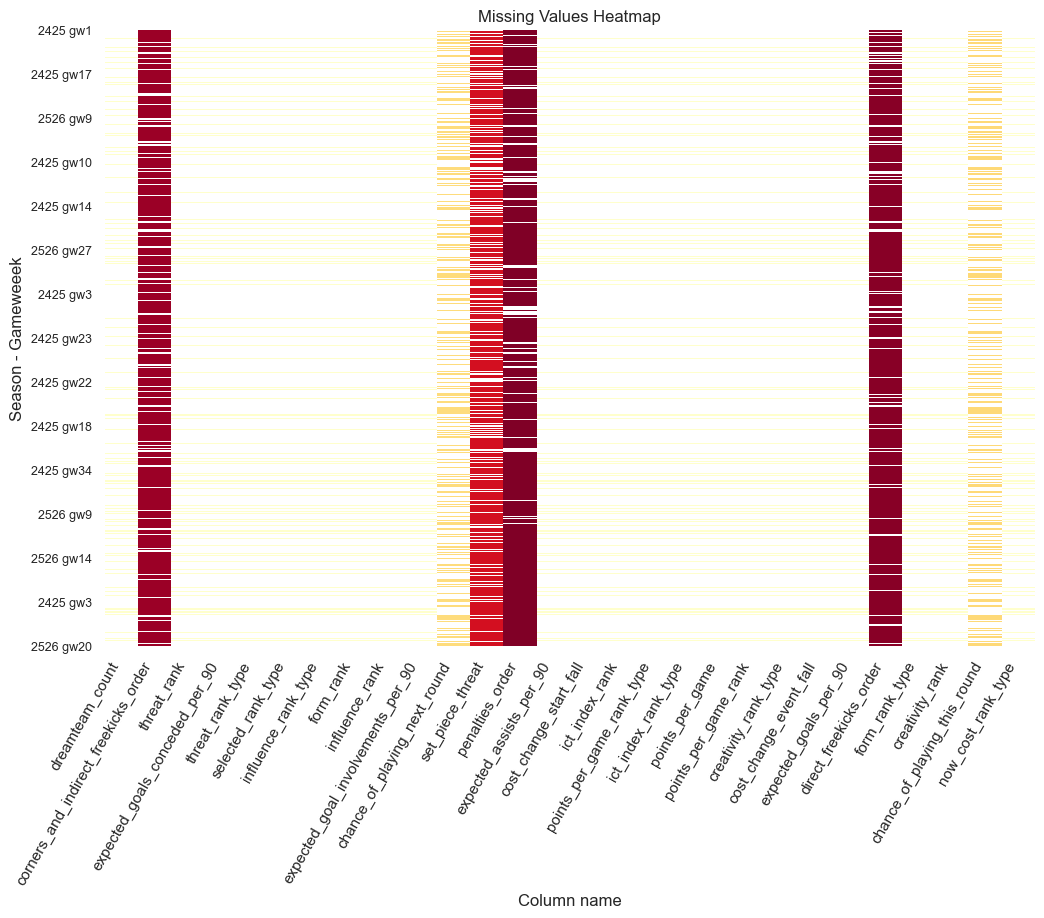

In [11]:
d = data.loc[:, data.isna().any()]
labels = data["season_id"].astype(str) + " gw" + data["gw_id"].astype(str)
plt.figure(figsize=(12, 8))
sns.heatmap(d.isna() * d.isna().mean(), mask=d.notna(), cmap='YlOrRd',
            cbar=False, yticklabels=False)

plt.title("Missing Values Heatmap")
plt.xticks(rotation=60, ha='right')

n_ticks = 15
y_positions = np.linspace(0, d.shape[0]-1, n_ticks)

plt.yticks(y_positions, labels.iloc[y_positions.astype(int)], fontsize=9)
plt.ylabel("Season - Gameweeek")
plt.xlabel("Column name")

plt.grid(axis='y', alpha=0.5)

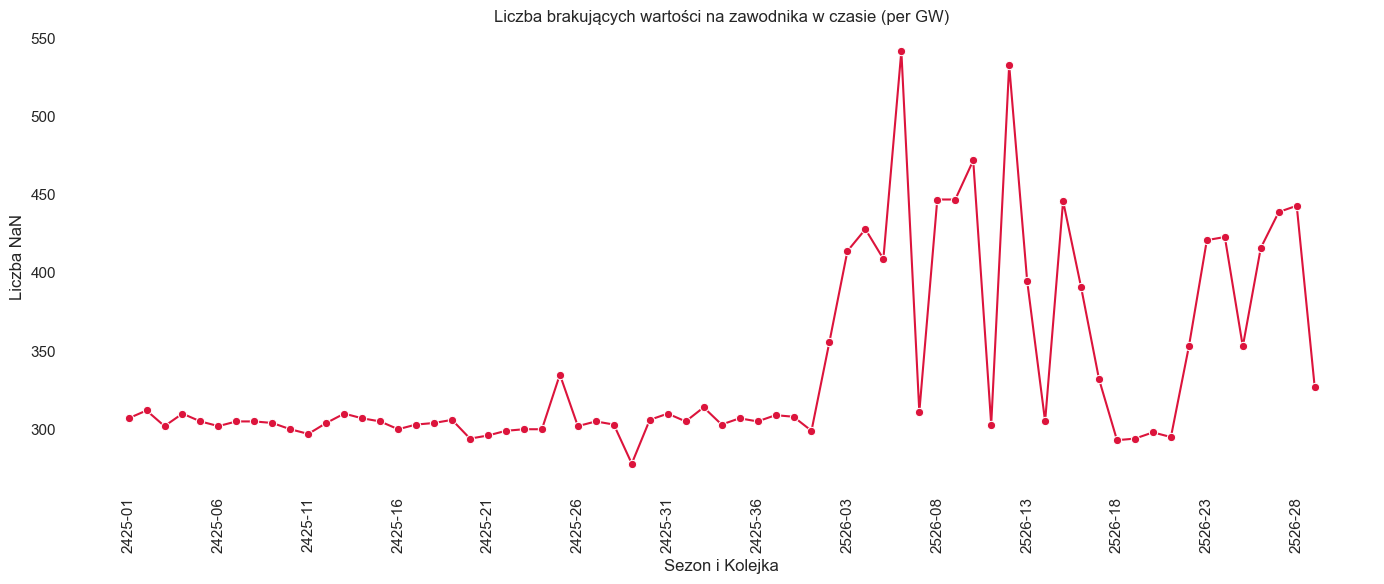

In [12]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=data.isna().sum(axis=1).groupby(data['season_id'].astype(str) + "-" + data['gw_id'].astype(str).str.zfill(2)).count(),
             color='crimson', marker='o')

plt.title("Liczba brakujących wartości na zawodnika w czasie (per GW)")
plt.ylabel("Liczba NaN")
plt.xlabel("Sezon i Kolejka")

plt.xticks(range(0, data[['season_id', 'gw_id']].drop_duplicates().shape[0], 5), rotation=90)
plt.tight_layout()
plt.grid(alpha=0.3)

In [14]:
data['position'] = data['position_id'].replace({
    "Goalkeeper": "GKP",
    "Defender": "DEF",
    "Midfielder": "MID",
    "Forward": "FWD"
})

In [15]:
data_w_nan = data.copy()

In [16]:
data_w_nan.position_id.unique()

<ArrowStringArray>
['Midfielder', 'Defender', 'Goalkeeper', 'Forward']
Length: 4, dtype: string

In [17]:
s[s<.3]

expected_goals_conceded_per_90       0.147416
selected_rank_type                   0.147416
form_rank                            0.147416
threat_rank                          0.147416
threat_rank_type                     0.147416
dreamteam_count                      0.147416
influence_rank                       0.147416
expected_goal_involvements_per_90    0.147416
influence_rank_type                  0.147416
expected_assists_per_90              0.147416
points_per_game_rank_type            0.147416
ict_index_rank_type                  0.147416
cost_change_start_fall               0.147416
ict_index_rank                       0.147416
points_per_game_rank                 0.147416
points_per_game                      0.147416
cost_change_event_fall               0.147416
creativity_rank_type                 0.147416
expected_goals_per_90                0.147416
form_rank_type                       0.147416
creativity_rank                      0.147416
now_cost_rank_type                

In [18]:
data_w_nan = data_w_nan.assign(
    nan_flag = np.where(data_w_nan[s[s < 0.2].index.to_list()].isna().any(axis=1), 1, 0)
)

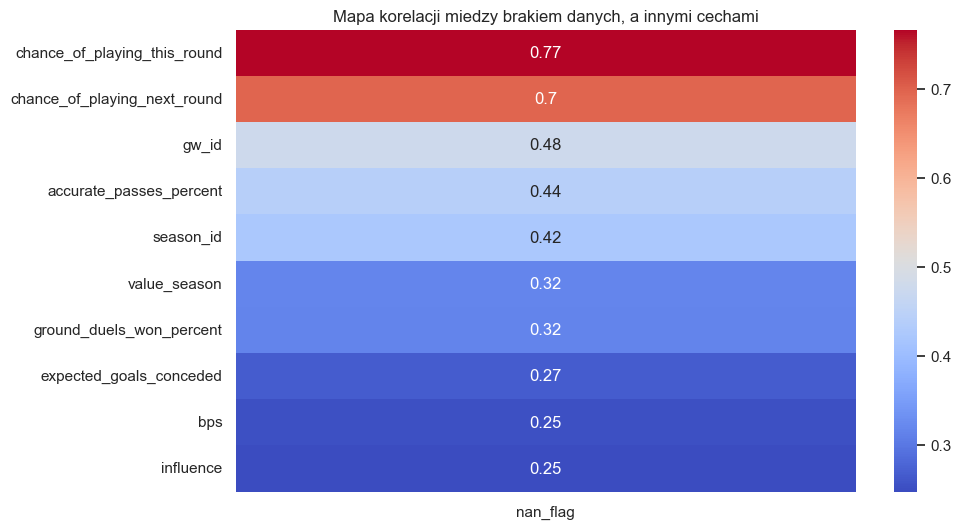

In [19]:
plt.figure(figsize=(10, 6))
plt.title("Mapa korelacji miedzy brakiem danych, a innymi cechami")
sns.heatmap(pd.DataFrame(data_w_nan.drop(columns=data_w_nan.select_dtypes(include=["object", "string"])).corr("pearson")\
                         .nan_flag.apply(np.abs).sort_values(ascending=False).dropna().head(11)).drop(["nan_flag"], axis=0),
            annot=True,
            cmap="coolwarm");

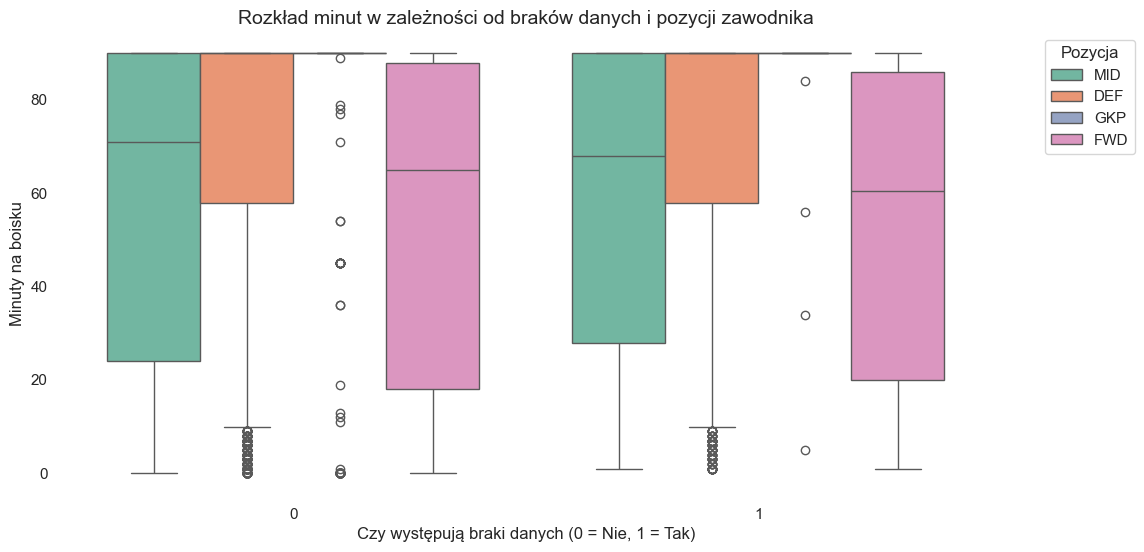

In [20]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=data_w_nan,
    x='nan_flag',
    y='minutes_played',
    hue='position',
    palette='Set2',
    orient="x"

)

plt.title("Rozkład minut w zależności od braków danych i pozycji zawodnika", fontsize=14)
plt.xlabel("Czy występują braki danych (0 = Nie, 1 = Tak)", fontsize=12)
plt.ylabel("Minuty na boisku", fontsize=12)

plt.legend(title='Pozycja', bbox_to_anchor=(1.05, 1), loc='upper left');


In [21]:
order_cols = [c for c in data.columns if "order" in c]
order_cols

['corners_and_indirect_freekicks_order',
 'penalties_order',
 'direct_freekicks_order']

In [22]:
data[order_cols].nunique()

corners_and_indirect_freekicks_order    7
penalties_order                         5
direct_freekicks_order                  6
dtype: int64

In [23]:
data[order_cols].apply(lambda x: x.unique())

corners_and_indirect_freekicks_order    [1, <NA>, 5, 3, 2, 4, 7, 6]
penalties_order                               [<NA>, 1, 2, 3, 4, 5]
direct_freekicks_order                     [<NA>, 1, 3, 2, 4, 6, 5]
dtype: object

In [24]:
def order_cols_imputation(df:pd.DataFrame, order_cols:list[str])->pd.DataFrame:

    fill_values = df[order_cols].max() + 1
    df[order_cols] = df[order_cols].fillna(fill_values)
    return df

In [25]:
data = order_cols_imputation(data, order_cols)

In [26]:
data[s[s>.8].index].isna().sum()

penalties_order                         0
direct_freekicks_order                  0
corners_and_indirect_freekicks_order    0
dtype: int64

In [27]:
chance_cols = [c for c in data.columns if "chance" in c and data[c].isna().sum()!=0]
chance_cols

['chance_of_playing_next_round', 'chance_of_playing_this_round']

In [28]:
data[chance_cols].sample(5)

,chance_of_playing_next_round,chance_of_playing_this_round
21002,100,100
17363,100,100
12544,100,100
13999,<NA>,<NA>
18272,<NA>,<NA>


In [29]:
data.groupby("season_id")[chance_cols].apply(lambda x: x.isna().sum())

,chance_of_playing_next_round,chance_of_playing_this_round
season_id,,
2425,4563,4737
2526,2733,2843


In [30]:
data[chance_cols].apply(lambda x: x.unique())

,chance_of_playing_next_round,chance_of_playing_this_round
0,<NA>,<NA>
1,75,0
2,100,100
3,0,75
4,25,50
5,50,25


In [31]:
data[chance_cols].apply(lambda x: x.value_counts())

,chance_of_playing_next_round,chance_of_playing_this_round
0,3236,2921
25,56,29
50,46,109
75,416,529
100,11702,11584


In [33]:
data.status_id.unique()

<ArrowStringArray>
['a', 'd', 's', 'i', 'n', 'u']
Length: 6, dtype: string

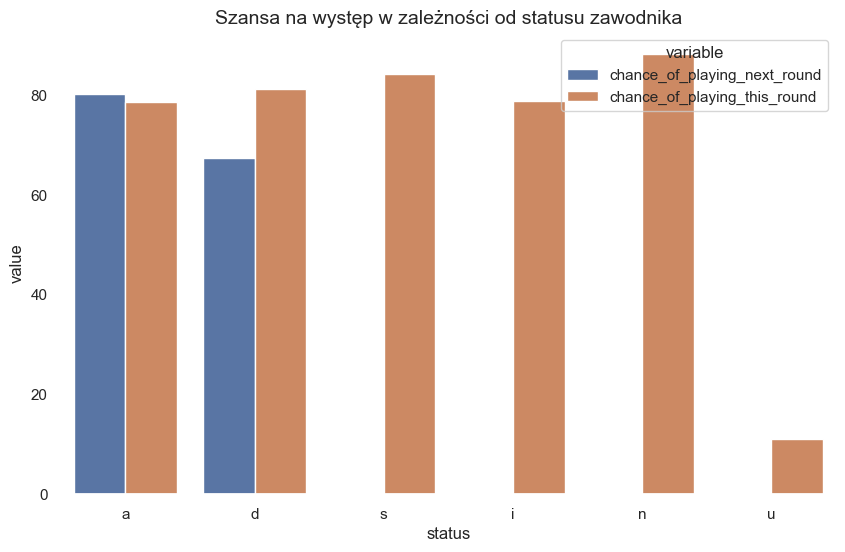

In [30]:
plt.figure(figsize=(10, 6))
plt.title("Szansa na występ w zależności od statusu zawodnika", fontsize=14)
sns.barplot(data=data.melt('status', chance_cols), x='status', y='value', hue='variable', errorbar=None);

In [35]:
data[data[chance_cols + ["status_id"]].isna().any(axis=1)][chance_cols + ["status_id"]].status_id.value_counts()

status_id
a    7313
d     145
s      57
i      50
n      11
u       4
Name: count, dtype: int64[pyarrow]

In [37]:
data[data.status_id.isin(["s", "i", "n", "u"])].chance_of_playing_next_round.isna().sum()

np.int64(0)

In [38]:
data[data.status_id.isin(["s", "i", "n", "u"])].chance_of_playing_this_round.isna().sum()

np.int64(122)

In [39]:
status_fill = {
    'a': 100,
    'i': 0,
    's': 0,
    'n': 0,
    'u': 0,
    'd': 75
}

In [40]:
data[chance_cols] = data.groupby("status_id")[chance_cols].transform(lambda x: x.fillna(status_fill.get(x.name, 0)))

In [41]:
data[chance_cols].isna().sum()

chance_of_playing_next_round    0
chance_of_playing_this_round    0
dtype: int64

In [42]:
data.isna().mean()[data.isna().mean()>0]

dreamteam_count                      0.147416
threat_rank                          0.147416
expected_goals_conceded_per_90       0.147416
threat_rank_type                     0.147416
selected_rank_type                   0.147416
influence_rank_type                  0.147416
form_rank                            0.147416
influence_rank                       0.147416
expected_goal_involvements_per_90    0.147416
set_piece_threat                     0.745605
expected_assists_per_90              0.147416
cost_change_start_fall               0.147416
ict_index_rank                       0.147416
points_per_game_rank_type            0.147416
ict_index_rank_type                  0.147416
points_per_game                      0.147416
points_per_game_rank                 0.147416
creativity_rank_type                 0.147416
cost_change_event_fall               0.147416
expected_goals_per_90                0.147416
form_rank_type                       0.147416
creativity_rank                   

In [43]:
data.dreamteam_count.unique()

<IntegerArray>
[0, <NA>, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Length: 14, dtype: Int64

In [45]:
dream_team_nan = data.loc[data.dreamteam_count.isna(), ["dreamteam_count", "web_name_id", "season_id", "team_name_id"]][["web_name_id", "season_id", "team_name_id"]].apply(lambda x: x.unique())

In [47]:
len(dream_team_nan.iloc[0].unique()), len(data[data.season_id==2526].web_name_id.unique())

(471, 539)

In [49]:
", ".join([p for p in dream_team_nan.iloc[0].unique() if p in data[data.dreamteam_count==5].web_name_id.unique()])

'Wood, Pickford, M.Salah, Watkins, Cucurella, Isak, Haaland, Palmer, Mbeumo, Aït-Nouri, João Pedro'

In [51]:
data.loc[(data.season_id==2425) & (data.web_name_id=="Tarkowski"), ["web_name_id", "season_id", "dreamteam_count"]].dreamteam_count.unique()

<IntegerArray>
[0, 1, 2]
Length: 3, dtype: Int64

In [53]:
data.loc[(data.season_id.isin([2425, 2526])) & (data.web_name_id=="Tarkowski"),
["web_name_id", "season_id", "dreamteam_count"]].drop_duplicates()

,web_name_id,season_id,dreamteam_count
24,Tarkowski,2425,0
34,Tarkowski,2425,1
47,Tarkowski,2425,2
57,Tarkowski,2526,0
58,Tarkowski,2526,<NA>


In [55]:
", ".join([p for p in data[data.dreamteam_count.isna()].web_name_id.unique() if p in data[data.season_id!=2526].web_name_id.unique()])[:100]

'Milner, Tarkowski, Barnes, Steele, Welbeck, Smith, Henderson, Clyne, Walker, Coleman, Wood, Casemiro'

In [56]:
data[data.season_id==2526].dreamteam_count.unique()

<IntegerArray>
[0, <NA>]
Length: 2, dtype: Int64

In [57]:
data.dreamteam_count = data.groupby("web_name_id")["dreamteam_count"].transform(lambda x: x.fillna(0))

In [58]:
data.dreamteam_count.isna().sum()

np.int64(0)

In [59]:
non_rank_cols = [c for c in s[s<.2].index if "rank" not in c and "dream" not in c]
non_rank_cols

['expected_goals_conceded_per_90',
 'expected_goal_involvements_per_90',
 'expected_assists_per_90',
 'cost_change_start_fall',
 'points_per_game',
 'cost_change_event_fall',
 'expected_goals_per_90']

In [60]:
data = data.drop(columns=[c for c in non_rank_cols if "expected" in c])

In [61]:
x_cols = ["xg", "xa", "expected_goal_involvements", "expected_goals_conceded"]

In [62]:
def exp_per_90(df:pd.DataFrame, x_cols:list[str])->pd.DataFrame:
    df = df.copy()
    new_x_cols_names = [f"{col}_per_90" for col in x_cols]
    df[new_x_cols_names] = df[x_cols].div(df.minutes_played / 90,axis=0).replace([np.inf, -np.inf], np.nan).fillna(0)
    return df

In [63]:
data = exp_per_90(data, x_cols)

In [64]:
data = data.drop(data.isna().mean()[data.isna().mean()>0].index, axis=1)

In [65]:
data.head()

,web_name_id,first_name_id,second_name_id,status_id,team_name_id,position_id,season_id,player_code_id,team_code_id,gw_id,match_id,recoveries,dreamteam_count,creativity,tackles_won_percent,corners_and_indirect_freekicks_order,bps,accurate_passes,transfers_in,expected_goals_conceded,ground_duels_won,duels_lost,tackles_won,finish_min,xgot,ep_this,was_fouled,accurate_long_balls_percent,accurate_passes_percent,ground_duels_won_percent,transfers_out,touches,tackles,interceptions,event_points,transfers_out_event,clearances,gk_accurate_long_balls,now_cost_rank,goals,team_goals_conceded,value_form,fouls_committed,threat,penalties_missed,bonus,blocks,high_claim,ep_next,shots_on_target,value_season,minutes_played,dribbled_past,expected_goals,influence,now_cost,chance_of_playing_next_round,penalties_scored,cost_change_start,ict_index,id,touches_opposition_box,cost_change_event,selected_rank,penalties_order,form,selected_by_percent,expected_assists,accurate_crosses,start_min,team_strength,final_third_passes,accurate_long_balls,aerial_duels_won,offsides,total_shots,total_points,expected_goal_involvements,xa,aerial_duels_won_percent,goals_prevented,chances_created,goals_conceded,xgot_faced,direct_freekicks_order,gk_accurate_passes,successful_dribbles,headed_clearances,big_chances_missed,saves,sweeper_actions,duels_won,accurate_crosses_percent,successful_dribbles_percent,assists,xg,transfers_in_event,chance_of_playing_this_round,position,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90
0,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,1,24-25-prem-everton-vs-brighton-&-hove-albion,0,0,43.8,50,1,10,28,513,0.45,4,2,2,82,0.0,1.6,0,33,85,80,421,48,4,0,2,421,0,0,172,0,0,0.4,1,4,0,0,2,0,1.6,0,0.4,82,0,0.0,22.4,5.0,0,0,0,7.0,134,2,0,471,6,2.0,0.1,0.11,2,0,3,2,1,0,0,0,2,0.11,0.11,0,0.0,3,0,0.0,7,0,0,0,0,0,0,4,29,0,0,0.0,513,0,MID,0.0,0.120732,0.120732,0.493902
1,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,2,24-25-prem-brighton-&-hove-albion-vs-mancheste...,2,0,66.2,0,1,22,22,2267,1.77,3,1,0,73,0.0,2.0,1,0,73,75,1548,42,1,1,2,635,2,0,177,0,1,0.4,1,12,0,0,0,0,1.0,1,0.8,73,0,0.16,28.6,5.0,0,0,0,10.7,134,2,0,448,6,2.0,0.1,0.15,1,0,3,6,0,0,0,2,4,0.31,0.04,0,0.0,1,0,0.0,7,0,1,0,0,0,0,3,100,100,0,0.16,1189,0,MID,0.19726,0.049315,0.382192,2.182192
2,Milner,James,Milner,d,Brighton,Midfielder,2425,15157,36,3,24-25-prem-arsenal-vs-brighton-&-hove-albion,0,0,66.3,0,1,24,2,4199,1.98,0,1,0,17,0.0,0.7,0,0,100,0,4535,4,0,1,1,1998,0,0,185,0,0,0.3,1,12,0,0,0,0,1.7,0,1.0,17,0,0.16,28.6,5.0,75,0,0,10.7,134,0,0,461,6,1.7,0.1,0.15,0,0,3,0,0,0,0,0,5,0.31,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,472,0,MID,0.0,0.0,1.641176,10.482353
3,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,38,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,0,0,66.3,0,8,27,0,5014,1.98,0,0,0,93,0.0,0.0,0,0,0,0,10991,1,0,0,1,0,0,0,192,0,0,0.0,0,12,0,0,0,0,0.0,0,1.2,1,0,0.16,28.6,5.0,100,0,0,10.7,134,0,0,586,6,0.2,0.0,0.15,0,93,3,1,0,0,0,0,6,0.31,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,0,0,MID,0.0,0.0,27.9,178.2
4,Milner,James,Milner,a,Brighton,Midfielder,2526,15157,36,1,25-26-prem-brighton-hove-albion-vs-fulham,0,0,0.1,0,5,3,1,14413,0.24,0,0,0,90,0.0,0.0,0,0,0,0,20304,1,0,0,1,497,0,0,283,0,1,0.0,0,0,0,0,0,0,-0.5,0,3.1,2,0,0.0,0.0,4.9,100,0,-1,0.0,170,0,0,467,1,0.0,0.1,0.0,0,0,3,0,0,0,0,0,1,0.0,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,113,0,MID,0.0,0.0,0.0,10.8


In [66]:
data.duplicated().sum()

np.int64(0)

In [67]:
data.shape

(22752, 103)

In [68]:
data.to_parquet(config.TIDY_DATA_PATH,
                engine='pyarrow',
                index=False)